In [3]:
import numpy as np
import os
import scipy.constants as sc
from scipy.interpolate import RegularGridInterpolator
import astropy.constants as const
import matplotlib.pyplot as plt
import csv
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [4]:
loaded_data = np.load("/Users/thomasmorgan/Documents/Group-Studies---Exoplanets/Group 1 Full Loop Code/exoplanetTg_data.npy")
loaded_data2 = np.load("/Users/thomasmorgan/Documents/Group-Studies---Exoplanets/Group 1 Full Loop Code/exoplanetAH_data.npy")
T_axis = loaded_data[:, 0] # Extract the temperature values
G_axis = loaded_data[:, 1]     # Extract the gravity values           
Z = loaded_data2               # Extract the A_H values

interp_func01 = RegularGridInterpolator((T_axis, G_axis), Z, method='linear', bounds_error=False, fill_value=None)

In [5]:
Ah_value = interp_func01((700, 5.5))  # Example: Interpolating A_H at T=600 K and g=2.5 m/s^2
print(f"Interpolated A_H value at T=600 K and g=2.5 m/s^2: {Ah_value}") 

Interpolated A_H value at T=600 K and g=2.5 m/s^2: 14.771909478696045


In [ ]:
# def pressure(t):
#     if t>= 600:
#         p = 0.015*t - 13
#     elif t<600:
#         p = -0.012*t + 3.2
#     return p

def pressure(t):
    # if t>= 600:
    #     p = 0.01*t - 10
    # elif t<600:
    #     p = -0.01*t + 2
	p = 2.5e-5*(t**2) - (0.0275*t) + 4.5
	return p

A_H_Array = []
feature_height_ppm_Array = []
scale_height_array = []
corrected_A_H_Array = []
interp = []

with open("/Users/thomasmorgan/Documents/Group-Studies---Exoplanets/Code/Data/19_top_f_h_planets17.02_16-44.csv", newline="") as PlanetaryParametersFile:   
	reader = csv.reader(PlanetaryParametersFile)
	header = next(reader)
	tsm_idx = header.index("pl_tsm")
	temp_idx = header.index("pl_Teq")
	gravity_idx = header.index("g_planet_cgs")
	rs_idx = header.index("st_rad")
	data = []
	planetNames = []
	tsm_values = []
	temp_values = []
	gravity_values = []
	rs_values = []
	for row in reader:
		row = [item.strip() for item in row]
		if len(row) == 0:
			continue
		name, *nums = row
		conv = [float(item) if item != "" else np.nan for item in nums]
		data.append(conv)
		planetNames.append(name)
		tsm = float(nums[tsm_idx - 1]) if nums[tsm_idx - 1] != "" else np.nan
		tsm_values.append(tsm)
		temp = float(nums[temp_idx - 1]) if nums[temp_idx - 1] != "" else np.nan
		temp_values.append(temp)
		gravity = float(nums[gravity_idx - 1]) if nums[gravity_idx - 1] != "" else np.nan
		gravity_values.append(gravity)
		rs = float(nums[rs_idx - 1]) if nums[rs_idx - 1] != "" else np.nan
		rs_values.append(rs)
	planetaryParameters = np.array(data, dtype=float)
	
rowCount= 0
while rowCount < len(planetaryParameters):
	PName = planetNames[rowCount]                                   ## planet name   
	# print(f"---Analysing Planet: {PName} ----")
	# print(f"Star Manitude: {planetaryParameters[rowCount][20]}")

    ## CHANGE INDEXES IF NEED BE ##
	
	Rp = planetaryParameters[rowCount][3]                           ## planet radius in units of Earth radii
	Mp = planetaryParameters[rowCount][2]                           ## planet mass in units of Earth masses
	Tp = planetaryParameters[rowCount][39]                          ## planet temperature in K
	mu = 4.877216515255627                                                       ## mean molecular weight in atomic mass units
	# Pcloud = 100
	Pcloud = 10**pressure(Tp)      
	# Pcloud = planetaryParameters[rowCount][43]                                             ## cloud deck pressure in bar
	# print(f"Cloud Deck Pressure: {Pcloud} bar")
	Pref = 0.01                                                     ## pressure at top of cloud deck in bar  
	Rs = planetaryParameters[rowCount][14]                          ## stellar radius in units of Solar radii
	# print(Rs)     
	Rp *= const.R_earth.value                                       ## Convert Rp from units of R_Earth to m
	Rs *= const.R_sun.value                                         ## Convert Rs from units of R_Sun to m
	Pcloud *= 1.0e5                                                 ## Convert Pcloud from bar to Pa
	Pref *= 1.0e5                                                   ## Convert Pref from bar to Pa
	mu *= sc.u                                                      ## Convert mu from atomic mass units to kg

	xsec_h2o = np.load('/Users/thomasmorgan/Documents/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/h2o_xsec.npy')
	lam_h2o = np.load('/Users/thomasmorgan/Documents/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/h2o_lam.npy')*1e6 # convert to microns
	P_h2o = np.power(10.0,np.load('/Users/thomasmorgan/Documents/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/h2o_P.npy')) # already in Pa
	T_h2o = np.load('/Users/thomasmorgan/Documents/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/h2o_T.npy')

	# Read in CO2 cross section data
	xsec_co2 = np.load('/Users/thomasmorgan/Documents/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co2_xsec.npy')
	lam_co2 = np.load('/Users/thomasmorgan/Documents/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co2_lam.npy')*1e6 # convert to microns
	P_co2 = np.power(10.0,np.load('/Users/thomasmorgan/Documents/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co2_P.npy')) # already in Pa
	T_co2 = np.load('/Users/thomasmorgan/Documents/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co2_T.npy')

	# Read in CH4 cross section data
	xsec_ch4 = np.load('/Users/thomasmorgan/Documents/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/ch4_xsec.npy')
	lam_ch4 = np.load('/Users/thomasmorgan/Documents/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/ch4_lam.npy')*1e6 # convert to microns
	P_ch4 = np.power(10.0,np.load('/Users/thomasmorgan/Documents/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/ch4_P.npy')) # already in Pa
	T_ch4 = np.load('/Users/thomasmorgan/Documents/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/ch4_T.npy')

	#read in CO cross section data
	xsec_co = np.load('/Users/thomasmorgan/Documents/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co_xsec.npy')
	lam_co = np.load('/Users/thomasmorgan/Documents/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co_lam.npy')*1e6 # convert to microns   
	P_co = np.power(10.0,np.load('/Users/thomasmorgan/Documents/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co_P.npy')) # already in Pa
	T_co = np.load('/Users/thomasmorgan/Documents/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/co_T.npy')

	# H2-H2 and He-H2 molecule pairs cause absorption through a process called "collision-induced absorption". This data is wavelength- and temperature-dependent, but not pressure-dependent.
	xsec_h2h2 = np.load('/Users/thomasmorgan/Documents/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/h2_h2_xsec.npy')
	lam_h2h2 = np.load('/Users/thomasmorgan/Documents/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/h2_h2_lam.npy')

	xsec_heh2 = np.load('/Users/thomasmorgan/Documents/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/he_h2_xsec.npy')
	lam_heh2 = np.load('/Users/thomasmorgan/Documents/Group-Studies---Exoplanets/GivenResources/cross_section_files/Cross_section_files/he_h2_lam.npy')
	# print('shape of xsec:', xsec_h2o.shape)
	# print('shape of lam:', lam_h2o.shape)
	# print('shape of P:', P_h2o.shape)
	# print('shape of P:', T_h2o.shape)

	P = np.logspace(2.0,-9, 200) * 1.0e5
	T = Tp*np.ones_like(P)
	n = P/(sc.k*T)
	rho = mu*n
	gp = planetaryParameters[rowCount][37] / 100.0 # convert from cgs to SI
	# print(f"Gravity: {gp} m/s^2")
	# gp = (sc.G * Mp * const.M_earth.value) / (Rp)**2
	# print(gp)
	r = np.zeros_like(P)
	g = np.zeros_like(P)
	i_Rp = np.argmin(np.abs(P-Pref))
	r[i_Rp] = Rp
	g[i_Rp] = gp

	interp_Ah_value = interp_func01((Tp, gp))  # Interpolating A_H at the planet's temperature and gravity
	interp.append(interp_Ah_value)

	# First, set up a dictionary which will contain all the log mixing ratios, and input the abundances of all molecules except H2 and He
	logX = dict()
	logX['h2o'] = -1.1
	logX['ch4'] = -1.74
	logX['co'] = -2.0
	logX['co2'] = -1.7
	#logX['nh3'] = -3.0

	## We'll also need to know the mean molecular weights of each molecule (here in units of amu) ##
	mmw = dict()
	mmw['h2o'] = 18.0
	mmw['ch4'] = 16.0
	mmw['co'] = 28.0
	mmw['co2'] = 44.0
	mmw['h2'] = 2.0
	mmw['he'] = 4.0
	
	# Now we can 'fill' the rest of the atmosphere with H2 and He, which are typically the most abudnant background gases.
	# Let's assume that the ratio of H2 to He is the same as that in the Sun, i.e. X_He/X_H2 = 0.17 (Asplund et al. 2009 shows that X_He/X_H = 0.085, and going from H to H2 means doubling that)
	# Then X_H2 + X_He = 1 - X_rest

	X_rest = np.sum([np.power(10.0,logX[key]) for key in logX.keys()])
	X_H2 = (1.0 - X_rest) / (1.0 + 0.17)
	X_He = 0.17 * X_H2

	# Now let's add H2 and He to the logX dictionary

	logX['h2'] = np.log10(X_H2)
	logX['he'] = np.log10(X_He)

	for i in range(i_Rp + 1, len(P)):
		g[i] = g[i_Rp] * r[i_Rp] * r[i_Rp] / (r[i-1] * r[i-1])
		r[i] = r[i-1] - ( sc.k * 0.5 * (T[i-1]+T[i]) / (mu * g[i]) ) * np.log(P[i]/P[i-1]) 

	for i in range(i_Rp-1, -1, -1):
		g[i] = g[i_Rp] * r[i_Rp] * r[i_Rp] / (r[i+1] * r[i+1])
		r[i] = r[i+1] - ( sc.k * 0.5 * (T[i+1]+T[i]) / (mu * g[i]) ) * np.log(P[i]/P[i+1])

	# With all the mixing ratios defined, we can calculate the mean molecular weight of the atmosphere, mu:
	mu = 0.0
	for mol in logX.keys():
		mu += np.power(10.0,logX[mol])*mmw[mol]

	# print("The mean molecular weight is:", mu)

	xsec_dict = dict()
	lam_dict = dict()
	P_dict = dict()
	T_dict = dict()

	

	lam = np.linspace(0.61,5.0,5000) # create a wavelength array in microns, which is the unit of the cross section data

	log_xsec_dict = dict()

	lamlam, PP = np.meshgrid(lam, P, indexing="ij")

	# ---- H2O ----
	interp_h2o = RegularGridInterpolator(
		(lam_h2o, P_h2o, T_h2o),
		xsec_h2o,
		method='linear', bounds_error=False,
		fill_value=None)
	log_xsec_dict['h2o'] = interp_h2o((lamlam, PP, T[0]))

	# ---- CO2 ----
	interp_co2 = RegularGridInterpolator(
		(lam_co2, P_co2, T_co2),
		xsec_co2,
		method='linear', bounds_error=False,
		fill_value=None
	)
	log_xsec_dict['co2'] = interp_co2((lamlam, PP, T[0]))

	# ---- CH4 ----
	interp_ch4 = RegularGridInterpolator(
		(lam_ch4, P_ch4, T_ch4),
		xsec_ch4,
		method='linear', bounds_error=False,
		fill_value=None
	)
	log_xsec_dict['ch4'] = interp_ch4((lamlam, PP, T[0]))

	interp_co2 = RegularGridInterpolator(
		(lam_co, P_co, T_co),
		xsec_co,
		method='linear', bounds_error=False,
		fill_value=None
	)
	log_xsec_dict['co'] = interp_co2((lamlam, PP, T[0]))

	log_cia_dict = dict()
	log_cia_dict['h2h2'] = np.interp(lam, lam_h2h2, xsec_h2h2)
	log_cia_dict['heh2'] = np.interp(lam, lam_heh2, xsec_heh2)

	sum_nsigma = np.zeros((len(lam), len(P)))
	for mol in log_xsec_dict.keys():
		sum_nsigma += n[np.newaxis,:]*np.power(10.0,logX[mol])*np.power(10.0,log_xsec_dict[mol])

	sum_nsigma += n[np.newaxis,:]*n[np.newaxis,:]*np.power(10.0,logX['h2'])*np.power(10.0,logX['h2'])*np.power(10.0,log_cia_dict['h2h2'])[:,np.newaxis]
	sum_nsigma += n[np.newaxis,:]*n[np.newaxis,:]*np.power(10.0,logX['he'])*np.power(10.0,logX['h2'])*np.power(10.0,log_cia_dict['heh2'])[:,np.newaxis]

	integral_gt_Rp = np.zeros((len(lam))) # initialise an array where we'll store the "r>Rp" integral
	integral_lt_Rp = np.zeros((len(lam))) # initialise an array where we'll store the "r<Rp" integral

	exptau = np.zeros((len(P),len(lam)))
	transit_depth = np.zeros((len(lam)))

	# Compute the total optical depth at each impact parameter and wavelength #

	opacity = sum_nsigma #(kappa+sigma)
	# For each layer of atmosphere

	for i in range(len(r)-1):

		s_tot = np.sqrt(r[i:]*r[i:]-r[i]*r[i])
		ds = s_tot[1:]-s_tot[:-1]

		tau_tot = np.sum((opacity[:, i:-1] + opacity[:, i+1:])*ds[np.newaxis,:],axis=-1)

		# If r[i] is deeper that the top of the cloud, the atmosphere here is fully opaque and tau is very large.
		if P[i] > Pcloud:
			tau_tot += 1000.0

		# We need e^(-tau) for the integral, so let's calculate that here. Adding 1.0-e-250 avoids errors when taking the log of this in cases where e^-tau is essentially zero.
		exptau[i, :] = np.exp(-1.0*tau_tot) + 1.0e-250


	# Compute transit depth terms. Note that we take an average of the i^th and (i+1)^th terms in the integrals.
	for i in range(len(r)-1):

		# Rays travelling through atmosphere above Rp
		if (r[i] >= Rp):
			integral_gt_Rp[:] += 0.5*((r[i]*(1.0 - exptau[i, :]) + (r[i+1]*(1.0 - exptau[i+1, :])))*(r[i+1] - r[i]))

		# Rays travelling through atmosphere below Rp
		if (r[i] < Rp):
			integral_lt_Rp[:] += 0.5*((r[i]*(exptau[i, :]) + (r[i+1]*(exptau[i+1, :])))*(r[i+1] - r[i]))

	# Compute effective transit depth (transmission spectrum) #
	transit_depth[:] = (Rp*Rp + 2.0*integral_gt_Rp[:] - 2.0*integral_lt_Rp[:])/(Rs*Rs)

	# np.savetxt(f'planet_spectrum_{PName}.txt', np.column_stack((lam, transit_depth)), header='Wavelength(micron)   Transit_Depth(rp^2/r*^2)', fmt='%10.6f')


    # 1. Load your spectrum data
	# loaded_spec = np.loadtxt("planet_spectrum_{PName}.txt".format(PName=PName))
	# lam_data = loaded_spec[:, 0]
	# depth_data = loaded_spec[:, 1]
	lam_data = lam
	depth_data = transit_depth

	# 2. Find Left Trough (4-4.3 um)
	left_mask = (lam_data >= 1.24) & (lam_data <= 1.29)   #H2O feature
	# left_mask = (lam_data >= 4.1) & (lam_data <= 4.15)   # CO2 feature
	# Extract values in that window
	left_depth_values = depth_data[left_mask]
	left_lam_values = lam_data[left_mask]
	# Take averages
	left_val = np.mean(left_depth_values)
	left_lam_target = np.mean(left_lam_values)

	# # 3. Find Right Trough (4.6-4.8 um)
	# right_mask = (lam_data >= 1.45) & (lam_data <= 1.6)   #H2O feature
	# # right_mask = (lam_data >= 4.6) & (lam_data <= 4.8)   # CO2 feature
	# right_val = np.min(depth_data[right_mask])
	# right_lam_target = lam_data[right_mask][np.argmin(depth_data[right_mask])]

	# 4. Identify the Peak region between those two troughs
	# peak_mask = (lam_data >= left_lam_target) & (lam_data <= right_lam_target)
	# peak_mask = (lam_data >= 4.25) & (lam_data <= 4.28)   # CO2 feature
	peak_mask = (lam_data >= 1.38) & (lam_data <= 1.41)   # H2O feature
	# Extract values in that window
	peak_region_depths = depth_data[peak_mask]
	peak_x_values = lam_data[peak_mask]

	# 5. Calculate Height and the Scatter Error
	peak_val = np.mean(peak_region_depths)
	peak_x_value = np.mean(peak_x_values)
	feature_height_ratio = (peak_val - left_val)
	feature_height_ppm = (peak_val - left_val) * 1e6
	feature_height_ppm_Array.append(feature_height_ppm)

	# The "Error" is the standard deviation of the points in the peak region
	# This represents the local variation/noise in your model
	peak_scatter_error_ppm = np.std(peak_region_depths) * 1e6

	# plt.figure(figsize=(20, 12))
	# plt.scatter(lam,transit_depth*1e6, s=3) #convert transit_depth into units of ppm
	# # # plt.scatter(left_lam_target, left_val*1e6, color='blue', label='Left Trough')
	# # # plt.scatter(peak_x_value, peak_val*1e6, color='red', label='Peak')
	# plt.xlabel('Wavelength (microns)')
	# plt.ylabel('Transit Depth (ppm)')
	# plt.title(f'Transmission Spectrum of {PName} with Clouds')
	# # # # plt.xlim([1.0,1.8])
	# # plt.xlim([3.0,5.0])
	# # # # plt.xlim([4.25, 4.275])
	# # # # plt.xlim([4.23, 4.29])
	# # # # plt.vlines(1.38, min(transit_depth)*1e6*0.95, max(transit_depth)*1e6*1.05, color='blue', label='Left Trough Region')
	# # # # plt.vlines(1.41, min(transit_depth)*1e6*0.95, max(transit_depth)*1e6*1.05, color='blue', label='Left Trough Region')
	# # # # # plt.vlines(4.265, min(transit_depth)*1e6*0.75, max(transit_depth)*1e6*1.25, color='blue', label='Left Trough Region')
	# # # # plt.vlines(4.275,min(transit_depth)*1e6*0.75,max(transit_depth)*1e6*1.25, color='green', label='Right Trough Region')
	# plt.show()

	print(f"--- {PName} ---")
	# print(f"Feature Height: {feature_height_ppm:.2f} ppm")
	# print(peak_x_value)
	# print(f"Model Scatter (Error): {peak_scatter_error_ppm:.2f} ppm")

	scale_height = (sc.k * Tp) / (mu * gp * sc.m_p)
	scale_height_array.append(scale_height)
	# print('Scale Height is,', scale_height)

	A_H = feature_height_ratio * (Rs ** 2) / (2*scale_height*Rp)
	A_H_Array.append(A_H)
	print('A_H =', A_H)

	corrected_Ah = A_H / interp_Ah_value
	corrected_A_H_Array.append(corrected_Ah)

	rowCount += 1

# print('Tsm values:', tsm_values)
# print('A/H values:', A_H_Array)


# import pandas as pd
# df = pd.DataFrame({
# 	'Planet Name': planetNames,
# # 	'Tsm': tsm_values,
# # 	'Temp': temp_values,
# 	'AH': A_H_Array,
# # 	'Feature Height (ppm)': feature_height_ppm_Array,
# # 	'scale height (m)': scale_height_array
# })
# df.to_csv('All_165_planets_no_clouds_modelled_AH.csv', index=False)

--- GJ 1214 b ---
A_H = 2.9393258292811444
--- GJ 3090 b ---
A_H = 3.9504717196621653
--- K2-138 d ---
A_H = 5.187930066042414
--- K2-138 f ---
A_H = 8.29215133847268
--- K2-18 b ---
A_H = 6.365749126763714
--- L 98-59 d ---
A_H = 4.697568751309605
--- LHS 1140 b ---
A_H = 6.568314107449799
--- TOI-1064 c ---
A_H = 4.503217754365902
--- TOI-1136 c ---
A_H = 5.410886349125693
--- TOI-1260 b ---
A_H = 5.416583098701855
--- TOI-1422 b ---
A_H = 5.7345249189485
--- TOI-1468 c ---
A_H = 5.641552666747789
--- TOI-1758 b ---
A_H = 3.7249512184192284
--- TOI-1799 b ---
A_H = 5.310491115621138


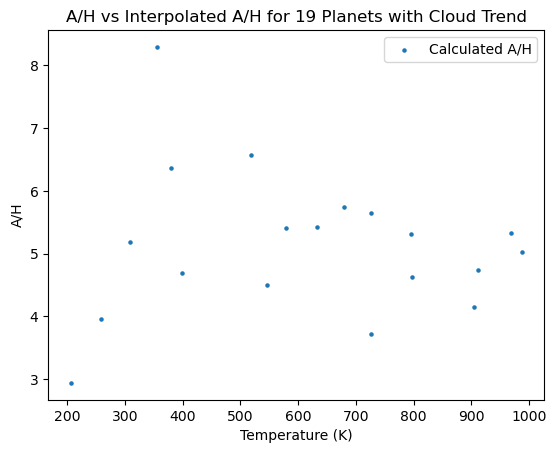

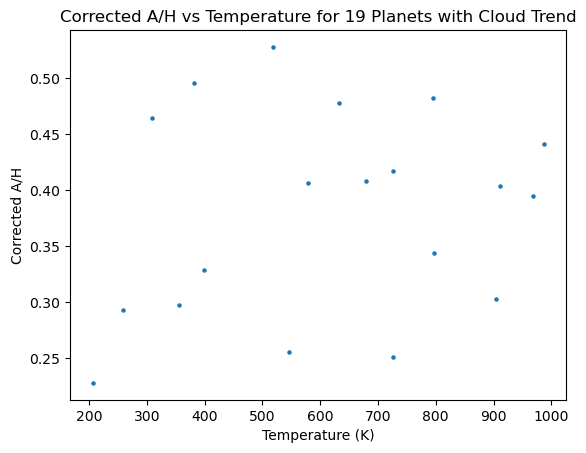

Text(0.5, 1.0, 'Cloud Pressure vs Temperature')

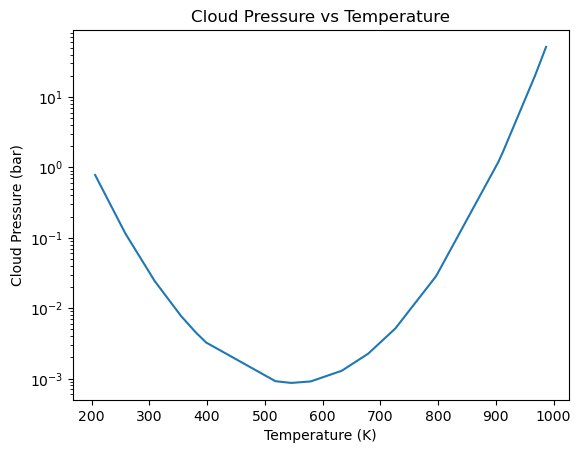

In [94]:
# plt.scatter(tsm_values, A_H_Array, marker='o')
# plt.xlabel('Tsm')
# plt.ylabel('A/H')
# plt.xlim(0, 200)
# plt.ylim(12, 20)
# plt.show()

# plt.scatter(tsm_values, feature_height_ppm_Array, marker='o')
# plt.xlabel('Tsm')
# plt.ylabel('Feature Height (ppm)')
# plt.xlim(0, 200)
# plt.ylim(0, 1000)
# plt.show()

plt.scatter(temp_values, A_H_Array, marker='o', s=5, label='Calculated A/H')
# plt.scatter(temp_values, interp, marker='x', s=5, color='red', label='Interpolated A/H')
plt.xlabel('Temperature (K)')
plt.ylabel('A/H')   
plt.title('A/H vs Interpolated A/H for 19 Planets with Cloud Trend')
# plt.xlim(0, 500)
# plt.ylim(10, 20)
# plt.ylim(5,24)
plt.legend()
plt.show()

plt.scatter(temp_values, corrected_A_H_Array, marker='o', s=5)
plt.xlabel('Temperature (K)')
plt.ylabel('Corrected A/H')   
plt.title('Corrected A/H vs Temperature for 19 Planets with Cloud Trend')
plt.show()

# plt.scatter(gravity_values, A_H_Array, marker='o', s=5)
# plt.xlabel('Gravity (cm/s^2)')
# plt.ylabel('A/H')   
# plt.title('A/H vs Gravity Trend for GJ 1214 b with No Clouds and Altering Gravity')
# plt.show()

# plt.scatter(rs_values, A_H_Array, marker='o')
# plt.xlabel('Stellar Radius (Solar Radii)')
# plt.ylabel('A/H')   
# plt.show()

# plt.scatter(temp_values, feature_height_ppm_Array, marker='o')
# plt.xlabel('Temperature (K)')
# plt.ylabel('Feature Height (ppm)')
# # plt.xlim(0, 500)
# # plt.ylim(0, 1000)
# plt.show()

# print(A_H_Array)

model = []

for i in temp_values:
    a = 10**pressure(i)
    model.append(a)

model = np.array(model)
sorted_indices = np.argsort(temp_values)
temp_values = np.array(temp_values)[sorted_indices]
model = model[sorted_indices]
    
plt.plot(temp_values, model, linestyle='-', label='A/H')
plt.xlabel('Temperature (K)')
plt.ylabel('Cloud Pressure (bar)')
plt.yscale('log')
plt.title('Cloud Pressure vs Temperature')

In [93]:
# loaded_spec = np.loadtxt("planet_spectrum_GJ 1214 b.txt")
# lam_data = loaded_spec[:, 0]
# depth_data = loaded_spec[:, 1]
# loaded_spec = np.loadtxt("planet_spectrum_GJ 1214 b1.txt")
# lam_data1 = loaded_spec[:, 0]
# depth_data1 = loaded_spec[:, 1]
# loaded_spec = np.loadtxt("planet_spectrum_GJ 1214 b2.txt")
# lam_data2 = loaded_spec[:, 0]
# depth_data2 = loaded_spec[:, 1]
# loaded_spec = np.loadtxt("planet_spectrum_GJ 1214 b3.txt")
# lam_data3 = loaded_spec[:, 0]
# depth_data3 = loaded_spec[:, 1]


# plt.figure(figsize=(20, 12))
# plt.plot(lam_data,depth_data*1e6, markersize=3, label='No Clouds') #convert transit_depth into units of ppm
# # plt.plot(lam_data1,depth_data1*1e6, markersize=3, color='green', label='With Clouds', alpha=0.8) #convert transit_depth into units of ppm
# # plt.plot(lam_data2,depth_data2*1e6, markersize=3, color='purple', label='With More Clouds', alpha=0.6) #convert transit_depth into units of ppm
# # plt.plot(lam_data3,depth_data3*1e6, markersize=3, color='red', label='With Even More Clouds', alpha=0.7) #convert transit_depth into units of ppm
# plt.xlabel('Wavelength (microns)')
# plt.ylabel('Transit Depth (ppm)')
# plt.title(f'Transmission Spectrum of GJ 1214b Showing the Effect of Clouds')
# plt.legend()
# plt.show()